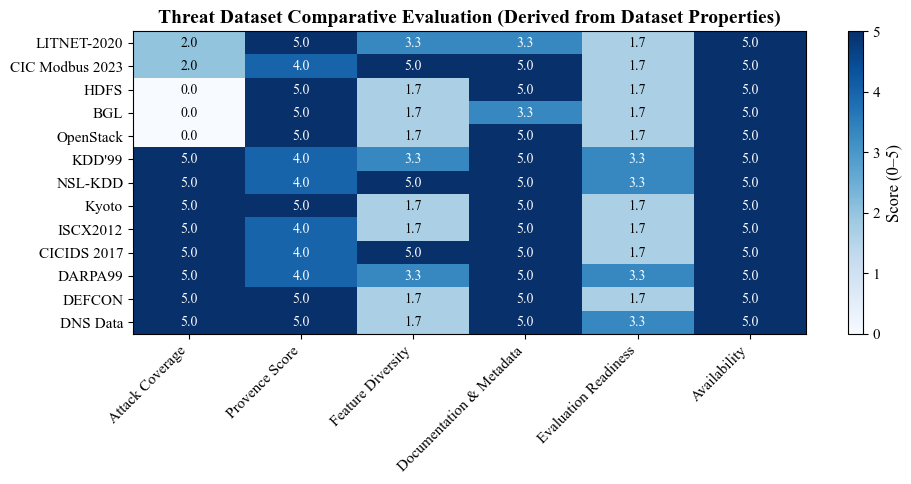

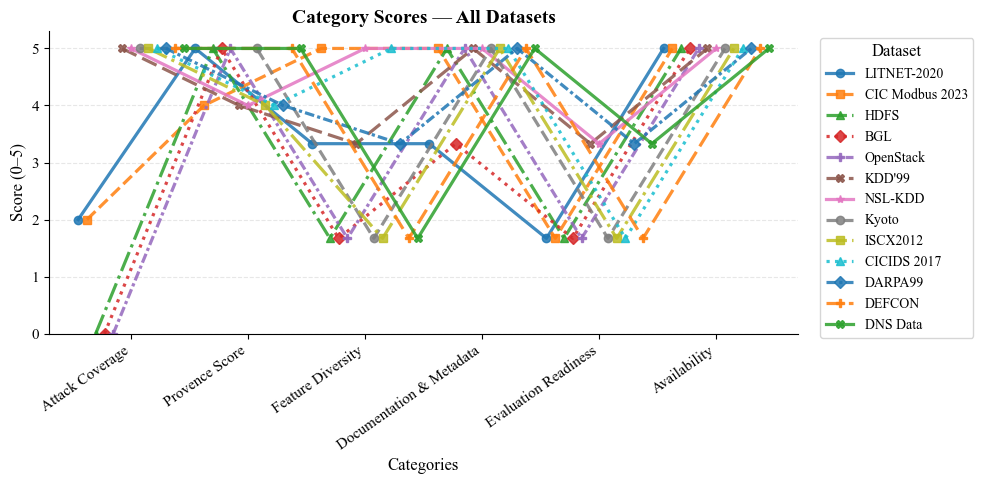

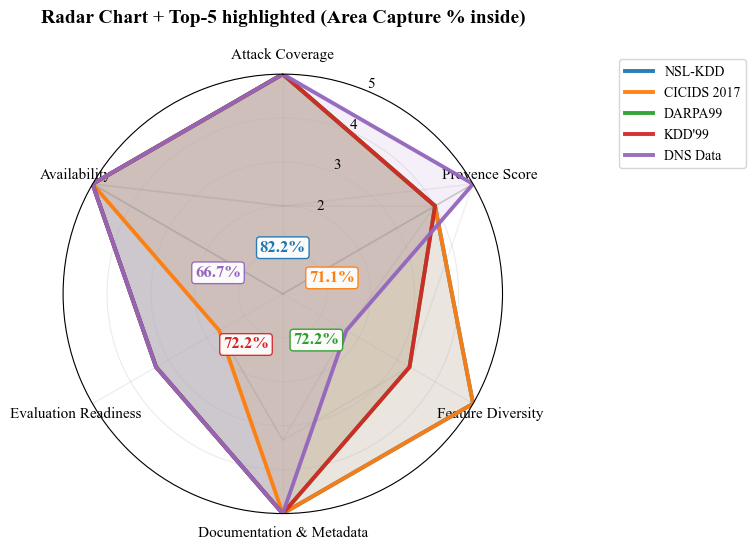

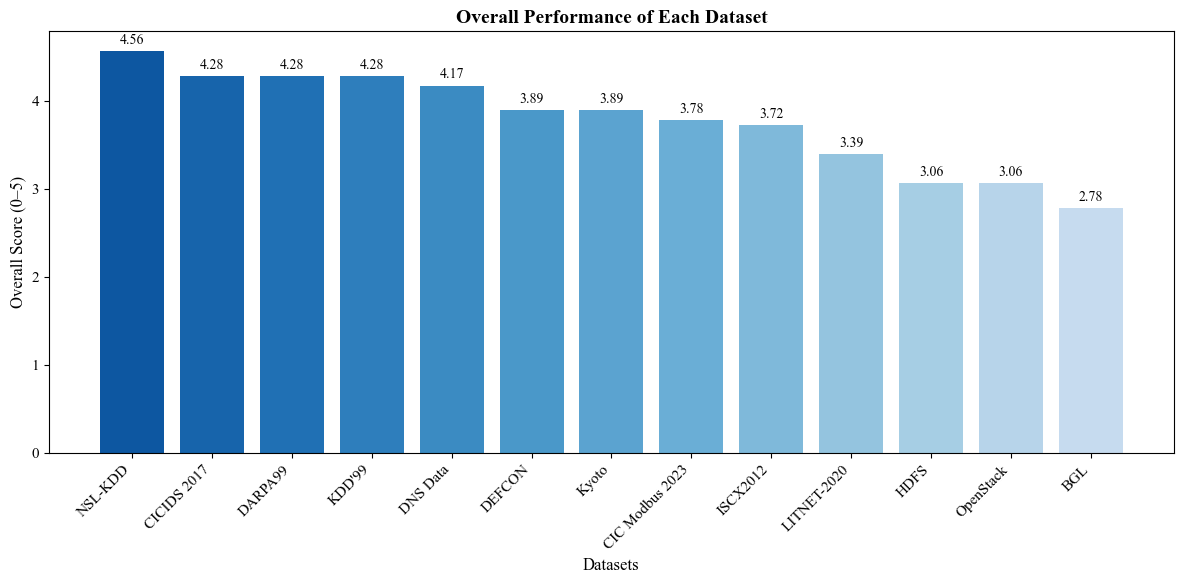

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------
# Global style: Times New Roman
# ------------------------------
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11
})

# ---------- 1) Load your property table ----------
src = Path("Full_Dataset1.csv")
df_raw = pd.read_csv(src)

# ---------- 1a) Fix the CSV header structure (2-row header) ----------
subheader = df_raw.iloc[0]
df = df_raw.iloc[1:].copy()

rename_map = {}
for col in df_raw.columns:
    subval = subheader.get(col, np.nan)
    if isinstance(subval, str) and subval.strip() and not str(subval).lower().startswith("unnamed"):
        rename_map[col] = subval.strip()
    else:
        rename_map[col] = col.strip() if isinstance(col, str) else col

df = df.rename(columns=rename_map)
df = df.loc[:, ~df.columns.astype(str).str.match(r"^Unnamed")]

df["Dataset"] = df["Dataset"].astype(str).str.strip()
df = df[df["Dataset"].notna() & (df["Dataset"] != "") & (df["Dataset"].str.lower() != "nan")].copy()

# ---------- 2) Scoring rules ----------
ATTACK_COLS = ["DoS", "DDoS", "U2R", "R2L", "Probe"]
FEATURE_COLS = ["Basic_Feature", "Traffic_Feature", "Content_Feature"]
EVAL_COLS    = ["Predefine_Split", "Balanced", "Labelled"]

def as_bool(x):
    if pd.isna(x):
        return False
    if isinstance(x, (int, float, np.integer, np.floating)):
        return bool(int(x))
    if isinstance(x, str):
        t = x.strip().lower()
        if t in {"true", "yes", "y", "1"}:
            return True
        if t in {"false", "no", "n", "0", ""}:
            return False
    return bool(x)

def score_attack_coverage(r):
    present = sum(as_bool(r.get(c, False)) for c in ATTACK_COLS)
    return round(5 * present / len(ATTACK_COLS), 2)

def score_provence(r):
    src_val = str(r.get("Source", "")).strip().lower()
    base = {"real": 5, "emulated": 3, "synthetic": 1}.get(src_val, 0)
    if as_bool(r.get("Regular_Traffic", False)):
        base += 1
    return float(min(5, base))

def score_feature_diversity(r):
    present = sum(as_bool(r.get(c, False)) for c in FEATURE_COLS)
    return round(5 * present / len(FEATURE_COLS), 2)

def score_metadata(r):
    ry = r.get("Release_Year", "")
    ry_ok = 0
    if not pd.isna(ry):
        s = str(ry).strip()
        if s not in {"", "0", "0.0", "nan", "none"}:
            ry_ok = 1

    checks = [
        ry_ok,
        int(as_bool(r.get("Meta_Data", False))),
        int(str(r.get("Data_Format", "")).strip() not in {"", "nan", "none"})
    ]
    return round(5 * sum(checks) / 3, 2)

def score_eval_readiness(r):
    present = sum(as_bool(r.get(c, False)) for c in EVAL_COLS)
    return round(5 * present / len(EVAL_COLS), 2)

def score_availability(r):
    a = str(r.get("Availability", "")).strip().lower().replace(" ", "")
    return float({
        "public": 5,
        "open": 5,
        "opensource": 5,
        "onrequest": 3,
        "n/a": 1,
        "no": 1
    }.get(a, 0))

# ---------- 3) Build scoring table ----------
rows = []
for _, r in df.iterrows():
    s1 = score_attack_coverage(r)
    s2 = score_provence(r)
    s3 = score_feature_diversity(r)
    s4 = score_metadata(r)
    s5 = score_eval_readiness(r)
    s6 = score_availability(r)

    rows.append({
        "Dataset": r["Dataset"],
        "Attack Coverage": s1,
        "Provence Score": s2,
        "Feature Diversity": s3,
        "Documentation & Metadata": s4,
        "Evaluation Readiness": s5,
        "Availability": s6,
        "Overall (Mean)": round(np.mean([s1, s2, s3, s4, s5, s6]), 2)
    })

scores = pd.DataFrame(rows).set_index("Dataset")

# ---------- 4) Save ----------
out_csv = Path("dataset_scores_table.csv")
scores.to_csv(out_csv)

# ---------- 5) Heatmap (blue; adaptive text colour) ----------
fig, ax = plt.subplots(figsize=(10, 5))
M = scores.drop(columns=["Overall (Mean)"]).values

cmap = plt.cm.Blues
im = ax.imshow(M, aspect="auto", cmap=cmap, vmin=0, vmax=5)

ax.set_xticks(np.arange(M.shape[1]))
ax.set_xticklabels(scores.drop(columns=["Overall (Mean)"]).columns, rotation=45, ha="right")
ax.set_yticks(np.arange(len(scores.index)))
ax.set_yticklabels(scores.index)

norm = plt.Normalize(vmin=0, vmax=5)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        value = float(M[i, j])
        bg_color = cmap(norm(value))
        brightness = (0.299 * bg_color[0] + 0.587 * bg_color[1] + 0.114 * bg_color[2])
        text_color = "white" if brightness < 0.5 else "black"
        ax.text(j, i, f"{value:.1f}", ha="center", va="center", color=text_color, fontsize=10)

ax.set_title("Threat Dataset Comparative Evaluation (Derived from Dataset Properties)", fontweight="bold")
fig.colorbar(im, ax=ax, label="Score (0–5)")
plt.tight_layout()
plt.show()

# ---------- 6) MULTI-LINE CHART: Category Scores — All Datasets (with larger x-shift per line) ----------
category_scores = scores.drop(columns=["Overall (Mean)"])
categories = list(category_scores.columns)
x = np.arange(len(categories))

ds_names = list(category_scores.index)
n = len(ds_names)

# Larger x-jitter so overlapping lines separate more
SHIFT_RANGE = 0.45   # was 0.28
offsets = np.linspace(-SHIFT_RANGE, SHIFT_RANGE, n) if n > 1 else np.array([0.0])

markers = ['o', 's', '^', 'D', 'P', 'X', '*']
linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 2))]

fig, ax = plt.subplots(figsize=(10, 5))

for i, ds in enumerate(ds_names):
    y = category_scores.loc[ds].values.astype(float)
    x_shift = x + offsets[i]
    ax.plot(
        x_shift, y,
        marker=markers[i % len(markers)],
        linestyle=linestyles[i % len(linestyles)],
        linewidth=2.3,
        alpha=0.85,
        label=ds
    )

ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=35, ha="right")
ax.set_xlim(x.min() - (SHIFT_RANGE + 0.25), x.max() + (SHIFT_RANGE + 0.25))
ax.set_ylim(0, 5.3)
ax.set_ylabel("Score (0–5)")
ax.set_xlabel("Categories")
ax.set_title("Category Scores — All Datasets", fontweight="bold")
ax.grid(True, axis='y', linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(title="Dataset", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

# ---------- 6b) RADAR: Top-k highlighted + Area Capture % placed in separate sections (non-overlapping) ----------
import numpy as np
import matplotlib.pyplot as plt

cats = [c for c in scores.columns if c != "Overall (Mean)"]
data = scores[cats].astype(float)

N = len(cats)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close loop

def closed_list(vals):
    v = vals.values.astype(float).tolist()
    return v + v[:1]

# ---- Radar area capture (%) ----
dtheta = 2 * np.pi / N

def radar_area(vals_closed):
    r = np.array(vals_closed, dtype=float)  # length N+1
    return 0.5 * np.sum(r[:-1] * r[1:] * np.sin(dtheta))

max_area = radar_area([5.0] * (N + 1))

def area_capture_pct(vals_closed):
    return 100.0 * radar_area(vals_closed) / max_area if max_area > 0 else 0.0

# choose top-k to highlight
k = min(5, len(scores))
topk = scores["Overall (Mean)"].sort_values(ascending=False).head(k).index.tolist()

highlight_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

ax.set_theta_offset(np.deg2rad(90))
ax.set_theta_direction(-1)

# background: all datasets faint (neutral grey)
for ds in data.index:
    vals = closed_list(data.loc[ds])
    ax.plot(angles, vals, linewidth=1.2, alpha=0.10, color="0.5")

# highlight top-k
for i, ds in enumerate(topk):
    vals = closed_list(data.loc[ds])
    c = highlight_colors[i % len(highlight_colors)]
    ax.plot(angles, vals, linewidth=2.8, alpha=0.95, color=c, label=ds)
    ax.fill(angles, vals, alpha=0.10, color=c)

# axes formatting
ax.set_xticks(angles[:-1])
ax.set_xticklabels(cats, fontsize=11)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_ylim(0, 5)
ax.grid(alpha=0.25)

ax.set_title("Radar Chart + Top-5 highlighted (Area Capture % inside)", fontweight="bold", pad=18)
ax.legend(bbox_to_anchor=(1.25, 1.05), loc="upper left")

# ---------- Area % labels placed in separate sectors near centre ----------
# Put each label in its own angular sector, evenly spaced around the centre,
# and stagger radii slightly so they never overlap.
label_thetas = np.linspace(0, 2*np.pi, k, endpoint=False)  # evenly spaced
label_radii  = np.linspace(1.05, 1.55, k)                  # small radial staggering

for i, ds in enumerate(topk):
    vals = closed_list(data.loc[ds])
    pct = area_capture_pct(vals)
    c = highlight_colors[i % len(highlight_colors)]

    th = label_thetas[i]
    rr = label_radii[i]

    ax.text(
        th, rr,
        f"{pct:.1f}%",
        ha="center", va="center",
        fontsize=12, fontweight="bold",
        color=c,
        bbox=dict(boxstyle="round,pad=0.20", facecolor="white", edgecolor=c, alpha=0.95)
    )

plt.tight_layout()
plt.show()




# ---------- 7) Overall performance bar chart (Opposite colour mapping: highest = light, lowest = dark) ----------
import numpy as np
import matplotlib.pyplot as plt

overall_scores = scores["Overall (Mean)"].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

# Opposite mapping: highest -> light, lowest -> dark
# For Blues: low values are light, high values are dark.
# So we generate colours from dark->light while bars are sorted high->low.
colors = plt.cm.Blues(np.linspace(0.85, 0.25, len(overall_scores)))

ax.bar(overall_scores.index, overall_scores.values, color=colors)

ax.set_title("Overall Performance of Each Dataset", fontweight="bold")
ax.set_ylabel("Overall Score (0–5)")
ax.set_xlabel("Datasets")
plt.xticks(rotation=45, ha="right")

for i, v in enumerate(overall_scores.values):
    ax.text(i, v + 0.05, f"{v:.2f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

